### Predictive Maintenance Pipeline


In [266]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os   
from dotenv import load_dotenv

### Data Pulling from Consentium IoT

In [267]:
load_dotenv(override=True) # Load environment variables from .env file, with override=True to ensure that any existing environment variables with the same names are overwritten by the values from the .env file. This is useful for development and testing purposes, allowing you to easily manage and switch between different sets of environment variables without affecting the global environment.
b_api_key = os.getenv("board_api_key").strip()  # Remove any leading/trailing whitespace  
r_api_key = os.getenv("receive_api_key").strip()   

# The Consentium REST API endpoint for receiving data
url = f"https://api.consentiumiot.com/getData" 
params = {
            "receiveKey": r_api_key,
            "boardKey": b_api_key,
            "limit": 50,  # Number of data points to retrieve
        }

In [268]:

response = requests.get(url,params=params)

# Check if request was successful
if response.status_code == 200:
    data = response.json()
    feeds = data['feeds']
    board = data['board']

    print(f"Board name : {board['name']}")
    print(f"Sensors    : {board['info1']}, {board['info2']}, {board['info3']}")
    print(f"Total rows : {len(feeds)}")

    # Push feeds into dataframe
    df = pd.DataFrame(feeds)
    print(df.head())
    print(df.columns.tolist())

else:
    print(f"Failed to fetch data: {response.status_code}")
    df = pd.DataFrame()  # empty fallback



Board name : esp32
Sensors    : Accel_x, Accel_y, Accel_z
Total rows : 142
                   updated_at  value1  value2  value3
0  2026-04-09T19:24:30.490000    0.01    0.21    1.16
1  2026-04-09T19:24:36.576000    0.02    0.22    1.12
2  2026-04-09T19:24:42.831000    0.02    0.22    1.14
3  2026-04-09T19:24:48.894000    0.01    0.22    1.14
4  2026-04-09T19:24:54.956000    0.02    0.21    1.13
['updated_at', 'value1', 'value2', 'value3']


In [269]:
df = df.rename(columns={
    'updated_at': 'timestamp',
    'value1':     'accel_x',
    'value2':     'accel_y',
    'value3':     'accel_z'
})

# Convert types
# Convert UTC timestamp to IST
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Kolkata')

# Remove timezone info if you don't need it displayed
df['timestamp'] = df['timestamp'].dt.tz_localize(None)
df['accel_x']   = pd.to_numeric(df['accel_x'], errors='coerce')
df['accel_y']   = pd.to_numeric(df['accel_y'], errors='coerce')
df['accel_z']   = pd.to_numeric(df['accel_z'], errors='coerce')

# Add window_id
df['window_id'] = df.index + 1


# Sort by timestamp ascending
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.tail(50).reset_index(drop=True)

# Reassign window_id after slicing
df['window_id'] = df.index + 1

df

,timestamp,accel_x,accel_y,accel_z,window_id
0,2026-04-10 01:03:53.333,0.01,0.23,1.14,1
1,2026-04-10 01:03:59.390,0.01,0.22,1.13,2
2,2026-04-10 01:04:05.455,0.01,0.22,1.13,3
3,2026-04-10 01:04:11.511,0.01,0.22,1.13,4
4,2026-04-10 01:04:17.606,0.01,0.23,1.13,5
5,2026-04-10 01:04:23.661,0.00,0.22,1.11,6
6,2026-04-10 01:04:29.797,0.01,0.22,1.13,7
7,2026-04-10 01:04:35.873,0.00,0.22,1.15,8
8,2026-04-10 01:04:41.977,0.00,0.22,1.14,9
9,2026-04-10 01:04:48.032,0.00,0.22,1.14,10


### Kalman Filter Implementation

In [270]:
def kalman_filter(noisy_data, Q, R,x_est, P):

    kalman_estimates = []
    for z in noisy_data:
        # Prediction step
        P_pred = P + Q

        # Update step
        K = P_pred / (P_pred + R)
        x_est = x_est + K * (z - x_est)
        P = (1 - K) * P_pred

        kalman_estimates.append(x_est)
    return kalman_estimates


Q = 0.12  # Process noise covariance
R = 0.25   # Measurement noise covariance

x_est = 0.0   # Initial state estimate
P = 1.0       # Initial error covariance


sensor_columns = [
    'accel_x', 
    'accel_y', 
    'accel_z'
]

# 3. Loop through them and create new "filtered" columns
for col in sensor_columns:
    new_col_name = f"filtered_{col}"
    
    # We apply the filter and assign it to the new column
    df[new_col_name] = kalman_filter(df[col],Q,R,x_est,P)

# Display the first few rows of the updated DataFrame
df['accel_total_rms'] = np.sqrt(df['filtered_accel_x']**2 + df['filtered_accel_y']**2 + df['filtered_accel_z']**2)
df.head()

,timestamp,accel_x,accel_y,accel_z,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,accel_total_rms
0,2026-04-10 01:03:53.333,0.01,0.23,1.14,1,0.008175,0.188029,0.931971,0.950785
1,2026-04-10 01:03:59.390,0.01,0.22,1.13,2,0.009206,0.206085,1.043807,1.063997
2,2026-04-10 01:04:05.455,0.01,0.22,1.13,3,0.009612,0.213195,1.087847,1.108582
3,2026-04-10 01:04:11.511,0.01,0.22,1.13,4,0.009805,0.216582,1.108828,1.129824
4,2026-04-10 01:04:17.606,0.01,0.23,1.13,5,0.009901,0.223215,1.119295,1.141378


In [271]:
# # Plotting the original and filtered data for one of the sensor columns
# plt.figure(figsize=(12, 6))
# plt.plot(df['strain_s2_microstrain'], label='Original strain_s2_microstrain', alpha=0.5)
# plt.plot(df['filtered_strain_s2_microstrain'], label='Filtered strain_s2_microstrain', alpha=0.8)
# plt.title('Original vs Filtered strain_s2_microstrain')
# plt.xlabel('Time')
# plt.ylabel('Value')
# plt.legend()
# plt.show()

### Threshold Values...

In [272]:
accel_threshold = 1.148  # Threshold for total RMS acceleration in g
strain_threshold = 500  # Threshold for strain in microstrain



### Raw Signal Processing

In [273]:
import matplotlib.pyplot as plt

# # Peak strain comparison across all 3 sensors 
# plt.figure(figsize=(14, 5))
# plt.plot(df['window_id'], df['filtered_strain_s1_microstrain'],
#          marker='o', label='S1 — L/4 span', color='cyan')
# plt.plot(df['window_id'], df['filtered_strain_s2_microstrain'],
#          marker='o', label='S2 — 3L/4 span', color='orange')
# plt.axhline(y=strain_threshold, color='red', linestyle='--', label='Safe threshold (500 µε)') # Adding a horizontal line to indicate the safe threshold
# plt.title('Peak Strain Across Sensor Positions Over Time')
# plt.xlabel('Window ID')
# plt.ylabel('Strain (µε)')
# plt.legend()
# plt.grid(True)
# plt.show()





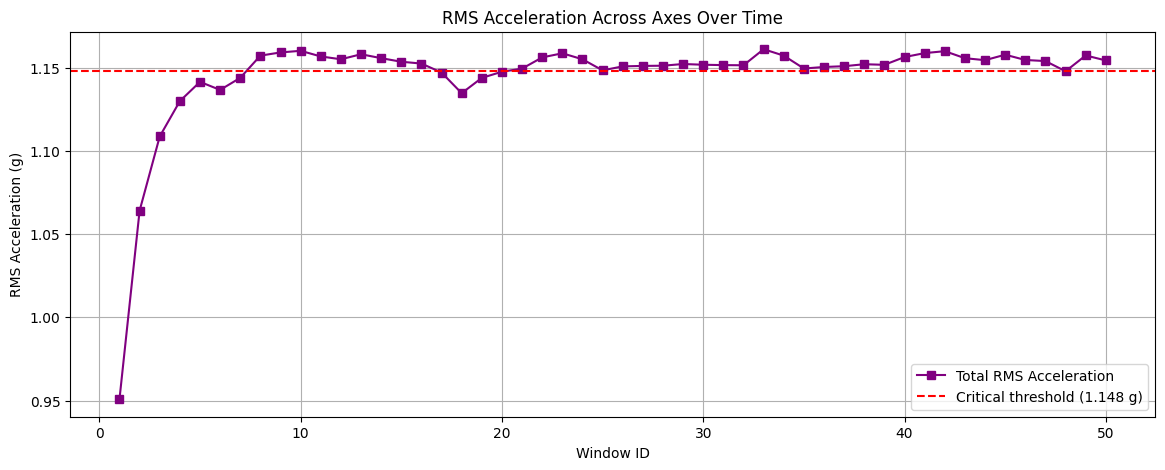

In [286]:
# RMS acceleration across all 3 axes 
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['accel_total_rms'],
         marker='s', label='Total RMS Acceleration', color='purple')
plt.axhline(y=accel_threshold, color='red', linestyle='--', label='Critical threshold (1.148 g)') # Adding a horizontal line to indicate the critical threshold
plt.title('RMS Acceleration Across Axes Over Time')
plt.xlabel('Window ID')
plt.ylabel('RMS Acceleration (g)')
plt.legend()
plt.grid(True)
plt.show()

In [275]:
# DataFrame Update
df.drop(['accel_x', 'accel_y', 'accel_z'], axis=1, inplace=True)
df.head()


,timestamp,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,accel_total_rms
0,2026-04-10 01:03:53.333,1,0.008175,0.188029,0.931971,0.950785
1,2026-04-10 01:03:59.390,2,0.009206,0.206085,1.043807,1.063997
2,2026-04-10 01:04:05.455,3,0.009612,0.213195,1.087847,1.108582
3,2026-04-10 01:04:11.511,4,0.009805,0.216582,1.108828,1.129824
4,2026-04-10 01:04:17.606,5,0.009901,0.223215,1.119295,1.141378


### Independent Anomaly Detection

In [276]:
# Anomaly detection based on thresholds

df['accel_anomaly'] = df['accel_total_rms'] > accel_threshold
# Displaying the anomalies detected
anomalies = df[df['accel_anomaly']] 
print("Anomalies detected:")

anomalies


Anomalies detected:


,timestamp,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,accel_total_rms,accel_anomaly
7,2026-04-10 01:04:35.873,8,0.003788,0.220418,1.135938,1.157131,True
8,2026-04-10 01:04:41.977,9,0.001919,0.220212,1.137941,1.159055,True
9,2026-04-10 01:04:48.032,10,0.000973,0.220107,1.138957,1.160030,True
10,2026-04-10 01:04:54.088,11,0.005425,0.224987,1.134539,1.156645,True
11,2026-04-10 01:05:00.145,12,0.007682,0.227459,1.132300,1.154946,True
12,2026-04-10 01:05:06.780,13,0.008825,0.223780,1.136098,1.157961,True
13,2026-04-10 01:05:12.832,14,0.009405,0.226848,1.133090,1.155613,True
14,2026-04-10 01:05:18.890,15,0.009698,0.223470,1.131566,1.153462,True
15,2026-04-10 01:05:25.018,16,0.009847,0.221759,1.130794,1.152375,True
20,2026-04-10 01:05:55.443,21,0.009995,0.221326,1.127775,1.149331,True


In [277]:
# Plotting anomalies on the strain graph
# plt.figure(figsize=(14, 5))
# plt.plot(df['window_id'], df['filtered_strain_s1_microstrain'], label='Filtered Strain S1', color='cyan')
# plt.plot(df['window_id'], df['filtered_strain_s2_microstrain'], label='Filtered Strain S2', color='orange')
# plt.scatter(df[df['strain_S1_anomaly']]['window_id'], df[df['strain_S1_anomaly']]['filtered_strain_s1_microstrain'], color='red', label='S1 Anomalies', zorder=5)
# plt.scatter(df[df['strain_S2_anomaly']]['window_id'], df[df['strain_S2_anomaly']]['filtered_strain_s2_microstrain'], color='magenta', label='S2 Anomalies', zorder=5)
# plt.axhline(y=strain_threshold, color='red', linestyle='--', label='Safe threshold (500 µε)') # Adding a horizontal line to indicate the safe threshold
# plt.title('Filtered Strain with Anomalies Highlighted')
# plt.xlabel('Window ID')
# plt.ylabel('Strain (µε)')
# plt.legend()
# plt.show()

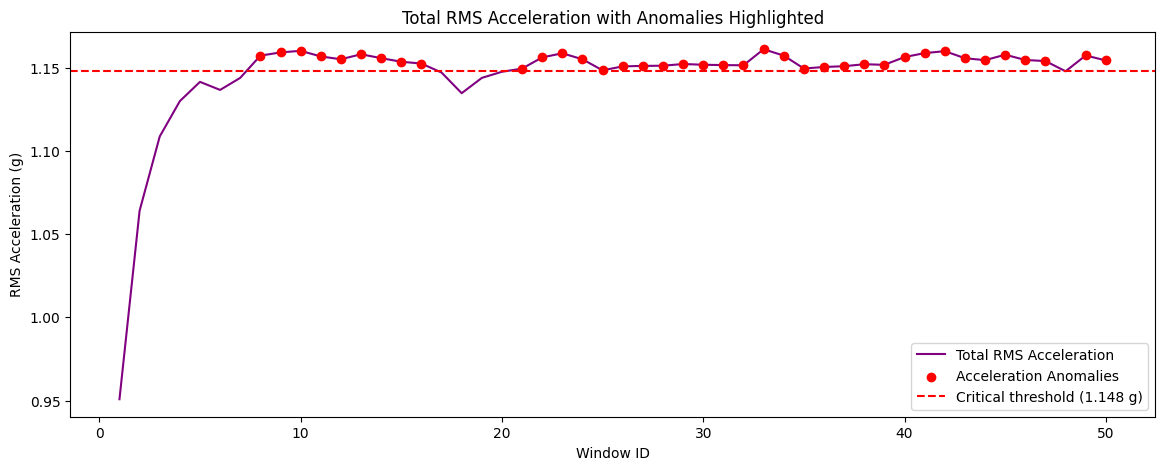

In [287]:
# Plotting anomalies on the acceleration graph
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['accel_total_rms'], label='Total RMS Acceleration', color='purple')
plt.scatter(df[df['accel_anomaly']]['window_id'], df[df['accel_anomaly']]['accel_total_rms'], color='red', label='Acceleration Anomalies', zorder=5)
plt.axhline(y=accel_threshold, color='red', linestyle='--', label='Critical threshold (1.148 g)') # Adding a horizontal line to indicate the critical threshold
plt.title('Total RMS Acceleration with Anomalies Highlighted')
plt.xlabel('Window ID')
plt.ylabel('RMS Acceleration (g)')
plt.legend()
plt.show()

### Health Score Analysis


In [279]:
# Health state classification based on detected anomalies

# def classify_health_state(row):
#     accel    = row['accel_anomaly']
#     s1       = row['strain_S1_anomaly']
#     s2       = row['strain_S2_anomaly']

#     if accel and (s1 or s2):
#         return 'Critical'
#     if accel or (s1 and s2):
#         return 'Warning'
#     if s1 or s2:
#         return 'Watch'
#     return 'Healthy'
    
# df['health_state'] = df.apply(classify_health_state, axis=1)
# # Displaying the health state classification results
# health_summary = df['health_state'].value_counts()
# print("Health State Summary:")
# print(health_summary)


In [280]:
# Displaying the health scores
# df[['window_id','strain_S1_anomaly','strain_S2_anomaly','accel_anomaly' ,'health_state']]

In [281]:
# PLotting health state distribution
# plt.figure(figsize=(8, 6))
# health_summary.plot(kind='bar', color=['yellow','green','red','orange'])
# plt.title('Distribution of Health States')
# plt.xlabel('Health State')
# plt.ylabel('Count')
# plt.show()

In [288]:
df.dropna(inplace=True) # Dropping any rows with NaN values that may have been introduced during filtering or anomaly detection
df.drop(['filtered_accel_x', 'filtered_accel_y', 'filtered_accel_z'], axis=1, inplace=True)
df.head()

,timestamp,window_id,accel_total_rms,accel_anomaly
0,2026-04-10 01:03:53.333,1,0.950785,False
1,2026-04-10 01:03:59.390,2,1.063997,False
2,2026-04-10 01:04:05.455,3,1.108582,False
3,2026-04-10 01:04:11.511,4,1.129824,False
4,2026-04-10 01:04:17.606,5,1.141378,False


### Trend Analysis on Rolling Window History

In [283]:
# # Performing Linear Regression to predict future conditions based on current sensor data
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split

# X = df[['accel_total_rms']]
# y = df['health_state'].apply(lambda x: 0 if x == 'Healthy' else (1 if x == 'Watch' else (2 if x == 'Warning' else 3)))  # Encoding health states as integers

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# from sklearn.metrics import mean_squared_error, r2_score
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"Mean Squared Error: {mse}")
# print(f"R^2 Score: {r2}")


In [284]:
# Confidence Score on the predictions
# confidence_scores = model.predict(X)
# df['confidence_score'] = confidence_scores.clip(0, 1) # Clipping to [0, 1] range for interpretability
# print(df[['window_id', 'confidence_score']])